<a href="https://colab.research.google.com/github/agustintamez/Actividades/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF8: Redes Neuronales Convolucionales

#### Hora Clase: N5

**Integrantes del equipo:**
* Agustin Azael Tamez Galaviz 2173925 IMTC
* Diego Antonio Garcia Cardiel 2046605 IMTC
* Luis Angel Araujo Solis 1411762 IMTC
* Zuriel Emiliano Jasso Davila 2177803 IMTC
* Juan Pablo Flores Perez 19033468 IMTC

# 1.- Cargar Librerias.
#### Importamos las herramientas de TensorFlow y Keras necesarias para construir una arquitectura convolucional, además de librerías para procesar datos numéricos y gráficas.

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

print("Librerías cargadas para el modelo convolucional.")

Librerías cargadas para el modelo convolucional.


# 2.- Cargar Datos.
#### Utilizamos la función load_data() para obtener el conjunto de datos MNIST, que contiene imágenes de dígitos escritos a mano del 0 al 9.

In [ ]:
# Carga de datos de entrenamiento y prueba
(train_data, train_labels), (test_data, test_labels) = datasets.mnist.load_data()

print(f"Set de entrenamiento: {train_data.shape}")
print(f"Set de prueba: {test_data.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Set de entrenamiento: (60000, 28, 28)
Set de prueba: (10000, 28, 28)


# 3.- Preprocesamiento De Datos.
##### Las imágenes deben normalizarse (pasar de valores 0-255 a 0-1) y redimensionarse para incluir el canal de color (gris), que es un requisito técnico de las capas convolucionales.

In [ ]:
# Normalización de píxeles
train_data = train_data.astype("float32") / 255
test_data = test_data.astype("float32") / 255

# Ajuste de dimensiones (Agregar canal de color: 28x28x1)
train_data = train_data.reshape((60000, 28, 28, 1))
test_data = test_data.reshape((10000, 28, 28, 1))

print("Preprocesamiento finalizado con éxito.")

Preprocesamiento finalizado con éxito.


# 4.- Seleccion Y Entrenamiento Del Modelo.
#### Definimos una estructura de red neuronal artificial (con capas de convolución y agrupación) y la entrenamos usando la función fit. La salida utiliza softmax para clasificar los 10 dígitos.

In [ ]:
# Definición de la estructura del modelo CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Capa de salida obligatoria
])

# Configuración: Optimizador Adam, Función de pérdida y Métrica de Exactitud
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento del modelo
print("Iniciando entrenamiento...")
model.fit(train_data, train_labels, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.9632 - loss: 0.1184
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9876 - loss: 0.0392
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9919 - loss: 0.0262
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9939 - loss: 0.0175
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.9959 - loss: 0.0136


# 5.- Prueba Del Modelo Y Predicciones
#### Mostramos la exactitud (accuracy) obtenida con datos que el modelo nunca ha visto y realizamos 5 predicciones individuales comparando el resultado real.

313/313 - 5s - 17ms/step - accuracy: 0.9890 - loss: 0.0337

Exactitud de predicción del modelo: 0.9890
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

--- Resultados de 5 Predicciones ---
Muestra 1: Predicción = 7 | Valor Real = 7
Muestra 2: Predicción = 2 | Valor Real = 2
Muestra 3: Predicción = 1 | Valor Real = 1
Muestra 4: Predicción = 0 | Valor Real = 0
Muestra 5: Predicción = 4 | Valor Real = 4


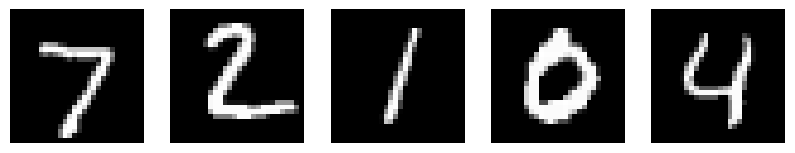

In [ ]:
# Evaluación con el conjunto de prueba
test_loss, test_acc = model.evaluate(test_data, test_labels, verbose=2)
print(f'\nExactitud de predicción del modelo: {test_acc:.4f}')

# Realización de 5 predicciones
predictions = model.predict(test_data)

print("\n--- Resultados de 5 Predicciones ---")
for i in range(5):
    prediccion = np.argmax(predictions[i])
    real = test_labels[i]
    print(f"Muestra {i+1}: Predicción = {prediccion} | Valor Real = {real}")

# Visualización de las imágenes probadas
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_data[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

# Responde Las Siguientes Preguntas
### ¿Cuántas épocas usaste para mejorar el rendimiento del modelo en comparación con la red neuronal prealimentada de la actividad 5?

##### Para ambos modelos se utilizaron 5 épocas de entrenamiento.
##### A pesar de usar la misma cantidad de iteraciones sobre los datos, el rendimiento mejoró significativamente en la Actividad 8 debido a la naturaleza de las capas convolucionales, que son mucho más eficientes para extraer características visuales que las capas densas simples.

###¿ Obtuviste un mejor rendimiento con este modelo o con el de la actividad 5? ¿Por qué?
##### si Obtuve un mejor rendimiento con este modelo por que este tipo de red está diseñada específicamente para analizar imágenes, lo que le permite identificar la forma de los números de manera mucho más precisa que la red anterior. Como resultado, el porcentaje de aciertos fue mayor y las predicciones fueron más exactas.